In [1]:
!conda install -y pandas pyarrow

/bin/bash: conda: command not found


In [2]:
%pip install pandas pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 17.4 MB/s  0:00:007.9 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 18.1 MB/s  0:00:01 18.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 13.1 MB/s  0:00:006.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]━━━━━━━━━━━ 2/3 [pandas]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

# Stepping out of 'notebooks/' and looking into 'data/raw/'
file_path = "../data/raw/jarvis_dft3d.parquet"
df = pd.read_parquet(file_path)

# Show the interactive data table
df.head()

,jid,formula,optb88vdw_bandgap,mbj_bandgap,formation_energy_peratom,ehull,epsx,epsy,epsz,slme,refractive_index,source_db
0,JVASP-90856,TiCuSiAs,0.000,NaN,-0.42762,0.0423,76.2300,76.2300,54.0402,NaN,8.296590,JARVIS_DFT3D
1,JVASP-86097,DyB6,0.000,NaN,-0.41596,0.0456,140.9742,140.9742,140.9742,NaN,11.873256,JARVIS_DFT3D
2,JVASP-64906,Be2OsRu,0.000,NaN,0.04847,0.3183,215.4488,215.4488,159.4368,NaN,14.027763,JARVIS_DFT3D
3,JVASP-98225,KBi,0.472,NaN,-0.44140,0.0000,NaN,NaN,NaN,NaN,NaN,JARVIS_DFT3D
4,JVASP-10,VSe2,0.000,0.0,-0.71026,0.0156,47.0290,47.0290,28.1625,NaN,6.382802,JARVIS_DFT3D


In [5]:
# 1. See how many total materials are in this dataset (rows, columns)
print(f"Dataset dimensions: {df.shape}")

# 2. See how much missing data (NaN values) you have in your target properties
print("\nMissing values per column:")
print(df[['optb88vdw_bandgap', 'mbj_bandgap', 'formation_energy_peratom', 'epsx']].isna().sum())

Dataset dimensions: (75993, 12)

Missing values per column:
optb88vdw_bandgap               0
mbj_bandgap                 56188
formation_energy_peratom        0
epsx                        23825
dtype: int64


In [6]:
# Create a clean subset where dielectric properties (epsx) actually exist
clean_df = df.dropna(subset=['epsx'])

# Quick statistical summary of the optical metrics
clean_df[['optb88vdw_bandgap', 'epsx', 'formation_energy_peratom']].describe()

,optb88vdw_bandgap,epsx,formation_energy_peratom
count,52168.000000,52168.000000,52168.000000
mean,0.660845,61.149387,-0.767296
std,1.383454,69.817924,1.083503
min,0.000000,0.012500,-4.385530
25%,0.000000,7.128575,-1.411417
50%,0.000000,30.782200,-0.516595
75%,0.554000,96.869975,-0.072247
max,17.968000,399.459200,5.359670


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 16.2 MB/s  0:00:00 15.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 16.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 17.8 MB/s  0:00:00 19.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]━━━ 6/8 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


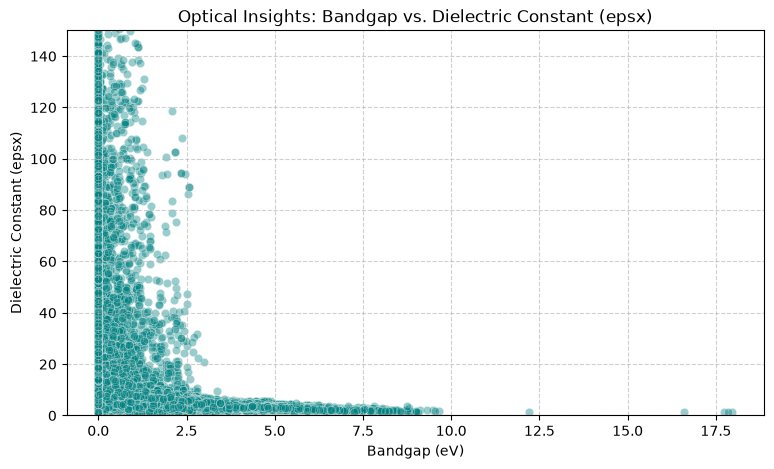

In [7]:
# 1. Install plotting libraries directly inside the notebook environment
%pip install matplotlib seaborn

# 2. Import them
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Create a scatter plot of Bandgap vs. Dielectric Constant (epsx)
plt.figure(figsize=(9, 5))
sns.scatterplot(data=clean_df, x='optb88vdw_bandgap', y='epsx', alpha=0.4, color='teal')

plt.title('Optical Insights: Bandgap vs. Dielectric Constant (epsx)')
plt.xlabel('Bandgap (eV)')
plt.ylabel('Dielectric Constant (epsx)')
plt.grid(True, linestyle='--', alpha=0.6)

# Clip the y-axis slightly if a few extreme outliers skew the view
plt.ylim(0, 150) 
plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the path to your raw data directory
data_dir = "../data/raw/"

# List of all your parquet files
files = [
    "jarvis_dft3d.parquet",
    "matbench_dielectric.parquet",
    "matbench_expt_gap.parquet",
    "matbench_mp_gap.parquet",
    "mp_dielectric.parquet",
    "mp_summary.parquet"
]

print("--- Multi-File Data Summary ---")

# Loop through each file to inspect dimensions and columns
for file_name in files:
    file_path = os.path.join(data_dir, file_name)
    
    # Quick safety check to make sure the file exists
    if os.path.exists(file_path):
        temp_df = pd.read_parquet(file_path)
        print(f"\n📄 {file_name}")
        print(f"   Dimensions: {temp_df.shape}")
        print(f"   Columns: {list(temp_df.columns)}")
    else:
        print(f"❌ {file_name} not found in path.")

--- Multi-File Data Summary ---

📄 jarvis_dft3d.parquet
   Dimensions: (75993, 12)
   Columns: ['jid', 'formula', 'optb88vdw_bandgap', 'mbj_bandgap', 'formation_energy_peratom', 'ehull', 'epsx', 'epsy', 'epsz', 'slme', 'refractive_index', 'source_db']

📄 matbench_dielectric.parquet
   Dimensions: (4764, 3)
   Columns: ['formula', 'refractive_index', 'source_db']

📄 matbench_expt_gap.parquet
   Dimensions: (4604, 4)
   Columns: ['formula', 'band_gap', 'gap_fidelity', 'source_db']

📄 matbench_mp_gap.parquet
   Dimensions: (106113, 4)
   Columns: ['formula', 'band_gap', 'gap_fidelity', 'source_db']

📄 mp_dielectric.parquet
   Dimensions: (7332, 7)
   Columns: ['material_id', 'n_mp', 'eps_electronic_iso', 'eps_total_iso', 'e_electronic_json', 'source_db', 'formula']

📄 mp_summary.parquet
   Dimensions: (65717, 14)
   Columns: ['material_id', 'formula', 'nelements', 'chemsys', 'band_gap', 'is_gap_direct', 'is_metal', 'formation_energy_per_atom', 'energy_above_hull', 'is_stable', 'theoretica

In [9]:
from pymatgen.core import Composition

def to_reduced_formula(formula):
    try:
        return Composition(formula).reduced_formula
    except Exception:
        return None

df["reduced_formula"] = df["formula"].apply(to_reduced_formula)

df[["formula", "reduced_formula"]].head(10)

ModuleNotFoundError: No module named 'pymatgen'

In [10]:
import sys
print(sys.executable)

/opt/homebrew/Cellar/jupyterlab/4.5.8_1/libexec/bin/python


In [11]:
%pip install pymatgen

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 11.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 18.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 18.6 MB/s  0:00:00 20.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 18.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 19.3 MB/s  0:00:00 19.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 19.8 MB/s  0:00:010.1 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 911.7/911.7 kB 18.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 17.7 MB/s  0:00:008.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 9.5 MB/s  0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43688 sha256=20

In [12]:
from pymatgen.core import Composition

In [13]:
import sys
print(sys.executable)

/opt/homebrew/Cellar/jupyterlab/4.5.8_1/libexec/bin/python


In [14]:
def to_reduced_formula(formula):
    try:
        return Composition(formula).reduced_formula
    except Exception:
        return None

df["reduced_formula"] = df["formula"].apply(to_reduced_formula)
df[["formula", "reduced_formula"]].head(10)


/opt/homebrew/Cellar/python@3.14/3.14.6/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:1126: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  val = self.func(instance)
/opt/homebrew/Cellar/python@3.14/3.14.6/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:1126: UserWarning: No Pauling electronegativity for Ar. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  val = self.func(instance)
/opt/homebrew/Cellar/python@3.14/3.14.6/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:1126: UserWarning: No Pauling electronegativity for Ne. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  val = self.func(instance)


,formula,reduced_formula
0,TiCuSiAs,TiCuSiAs
1,DyB6,DyB6
2,Be2OsRu,Be2OsRu
3,KBi,KBi
4,VSe2,VSe2
5,TbMnSi,TbMnSi
6,Ba4NaBi,Ba4NaBi
7,SrFeO3,SrFeO3
8,LuNi4Sn,LuNi4Sn
9,MoW3Se2S6,MoW3(SeS3)2


In [15]:
df["reduced_formula"].isna().sum()

np.int64(0)

In [16]:
df["reduced_formula"].nunique()

51889

In [17]:
df["reduced_formula"].value_counts().head(20)

reduced_formula
Li7Mn2(CoO4)3    100
Li4MnCo2O7       100
SiO2              88
CdI2              58
C                 52
VO2               47
LiVF4             41
LiMnPO4           40
VOF               39
TiO2              38
FeOF              35
BN                35
MnO2              34
Li7Mn4CoO12       34
Li3MnCoO5         34
Si                32
VOF3              31
LiFeSiO4          31
CoO2              30
MnOF              28
Name: count, dtype: int64

In [18]:
# Make one clean task table for band gap prediction
bandgap_df = df[["reduced_formula", "optb88vdw_bandgap"]].copy()
bandgap_df = bandgap_df.dropna(subset=["optb88vdw_bandgap"])

# Aggregate duplicate formulas by median target
bandgap_df = (
    bandgap_df
    .groupby("reduced_formula", as_index=False)
    .median(numeric_only=True)
)

bandgap_df.head(10)


,reduced_formula,optb88vdw_bandgap
0,Ac,0.0
1,Ac(AgGe)2,0.0
2,Ac(AlAg)2,0.0
3,Ac(AlSi)2,0.0
4,Ac(BIr)2,0.0
5,Ac(BOs)2,0.0
6,Ac(BRu)2,0.0
7,Ac(CdRh)2,0.0
8,Ac(CoGe)2,0.0
9,Ac(CuSi)2,0.0


In [19]:
bandgap_df.shape

(51889, 2)

In [20]:
%pip install matminer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 15.9 MB/s  0:00:00 12.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 17.6 MB/s  0:00:00.8 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 15.7 MB/s  0:00:00 15.9 MB/s eta 0:00:01
  Attempting uninstall: pandas━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━ 4/7 [pymongo]
    Found existing installation: pandas 3.0.338;2;249;38;114m╸━━━━━━━━━━━━━━━━━ 4/7 [pymongo]
    Uninstalling pandas-3.0.3:━━━━━━━━━╸━━━━━━━━━━━━━━━━━ 4/7 [pymongo]
      Successfully uninstalled pandas-3.0.3╸━━━━━━━━━━━━━━━━━ 4/7 [pymongo]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matminer]━━━━━━━━━ 5/7 [pandas]
Note: you may need to restart the kernel to use updated packages.


In [21]:
from pymatgen.core import Composition

bandgap_df["composition"] = bandgap_df["reduced_formula"].apply(
    Composition
)

bandgap_df[["reduced_formula", "composition"]].head()

,reduced_formula,composition
0,Ac,{Ac: 1.0}
1,Ac(AgGe)2,"{Ac: 1.0, Ag: 2.0, Ge: 2.0}"
2,Ac(AlAg)2,"{Ac: 1.0, Al: 2.0, Ag: 2.0}"
3,Ac(AlSi)2,"{Ac: 1.0, Al: 2.0, Si: 2.0}"
4,Ac(BIr)2,"{Ac: 1.0, B: 2.0, Ir: 2.0}"


In [22]:
sample = bandgap_df.head(10).copy()

In [23]:
from matminer.featurizers.composition import ElementProperty

featurizer = ElementProperty.from_preset("magpie")

/opt/homebrew/Cellar/jupyterlab/4.5.8_1/libexec/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
sample_features = featurizer.featurize_dataframe(
    sample,
    col_id="composition",
    ignore_errors=True
)

ElementProperty: 100%|████████████████████████| 10/10 [00:00<00:00, 118.77it/s]


In [25]:
sample_features.shape

(10, 135)

In [26]:
full_bandgap_features = featurizer.featurize_dataframe(
    bandgap_df.copy(),
    col_id="composition",
    ignore_errors=True,
    pbar=True
)

ElementProperty: 100%|███████████████████| 51889/51889 [23:46<00:00, 36.38it/s]


In [27]:
full_bandgap_features.shape


(51889, 135)

In [28]:
full_bandgap_features.head()

,reduced_formula,optb88vdw_bandgap,composition,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,Ac,0.0,{Ac: 1.0},89.0,89.0,0.0,89.0,0.00,89.0,14.0,...,0.0,0.0,0.0,0.0,225.0,225.0,0.0,225.0,0.00,225.0
1,Ac(AgGe)2,0.0,"{Ac: 1.0, Ag: 2.0, Ge: 2.0}",32.0,89.0,57.0,49.4,15.84,32.0,14.0,...,0.0,0.0,0.0,0.0,225.0,225.0,0.0,225.0,0.00,225.0
2,Ac(AlAg)2,0.0,"{Ac: 1.0, Al: 2.0, Ag: 2.0}",13.0,89.0,76.0,41.8,23.04,13.0,14.0,...,0.0,0.0,0.0,0.0,225.0,225.0,0.0,225.0,0.00,225.0
3,Ac(AlSi)2,0.0,"{Ac: 1.0, Al: 2.0, Si: 2.0}",13.0,89.0,76.0,28.6,24.16,13.0,14.0,...,0.0,0.0,0.0,0.0,225.0,227.0,2.0,225.8,0.96,225.0
4,Ac(BIr)2,0.0,"{Ac: 1.0, B: 2.0, Ir: 2.0}",5.0,89.0,84.0,50.6,36.48,5.0,14.0,...,0.0,0.0,0.0,0.0,166.0,225.0,59.0,201.4,28.32,166.0


In [29]:
full_bandgap_features.to_parquet(
    "data/processed/bandgap_features.parquet",
    index=False
)

ArrowInvalid: ("Could not convert Composition('Ac1') with type Composition: did not recognize Python value type when inferring an Arrow data type", 'Conversion failed for column composition with type object')

In [30]:
full_bandgap_features.columns

Index(['reduced_formula', 'optb88vdw_bandgap', 'composition',
       'MagpieData minimum Number', 'MagpieData maximum Number',
       'MagpieData range Number', 'MagpieData mean Number',
       'MagpieData avg_dev Number', 'MagpieData mode Number',
       'MagpieData minimum MendeleevNumber',
       ...
       'MagpieData range GSmagmom', 'MagpieData mean GSmagmom',
       'MagpieData avg_dev GSmagmom', 'MagpieData mode GSmagmom',
       'MagpieData minimum SpaceGroupNumber',
       'MagpieData maximum SpaceGroupNumber',
       'MagpieData range SpaceGroupNumber', 'MagpieData mean SpaceGroupNumber',
       'MagpieData avg_dev SpaceGroupNumber',
       'MagpieData mode SpaceGroupNumber'],
      dtype='str', length=135)

In [31]:
full_bandgap_features = full_bandgap_features.drop(
    columns=["composition"]
)

In [32]:
full_bandgap_features.to_parquet(
    "data/processed/bandgap_features.parquet",
    index=False
)

OSError: Cannot save file into a non-existent directory: 'data/processed'

In [33]:
import os
os.makedirs("data/processed", exist_ok=True)

In [34]:
full_bandgap_features.to_parquet("data/processed/bandgap_features.parquet", index=False)

In [35]:
import os
os.path.exists("data/processed/bandgap_features.parquet")

True

In [36]:
import pandas as pd

check_df = pd.read_parquet("data/processed/bandgap_features.parquet")
check_df.shape

(51889, 134)

In [37]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

check_df = pd.read_parquet("data/processed/bandgap_features.parquet")

X = check_df.drop(columns=["optb88vdw_bandgap"])
y = check_df["optb88vdw_bandgap"]
groups = check_df["reduced_formula"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

train_df = check_df.iloc[train_idx].copy()
test_df = check_df.iloc[test_idx].copy()

train_df.shape, test_df.shape

((44105, 134), (7784, 134))

In [38]:
train_df.to_parquet("data/processed/bandgap_train.parquet", index=False)
test_df.to_parquet("data/processed/bandgap_test.parquet", index=False)

In [39]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

check_df = pd.read_parquet("data/processed/bandgap_features.parquet")

X = check_df.drop(columns=["optb88vdw_bandgap"])
y = check_df["optb88vdw_bandgap"]
groups = check_df["reduced_formula"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

train_df = check_df.iloc[train_idx].copy()
test_df = check_df.iloc[test_idx].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (44105, 134)
Test shape: (7784, 134)


In [40]:
train_df.to_parquet(
    "data/processed/bandgap_train.parquet",
    index=False
)

test_df.to_parquet(
    "data/processed/bandgap_test.parquet",
    index=False
)

In [41]:
train_df.shape

(44105, 134)

In [42]:
test_df.shape

(7784, 134)